# Project 3 — Loan Portfolio Risk & Recovery Intelligence (Lending Club)



## Executive Summary (Portfolio Risk Playbook)

### Key Findings (What matters)
- **Loss concentration is extreme:** the **top 20% loss-making loans contribute ~48% of total economic loss** (Pareto effect).
- **Tenor is a structural risk amplifier:** **60-month loans show materially higher default rates and higher loss per default** than 36-month loans.
- **Pricing only partly compensates risk:** default rates rise steadily with interest rate, and **loss rate flips from profit to loss around ~16–18%**, indicating an adverse-selection zone.
- **Grade matters more than borrower demographics:** default rate increases monotonically from **A → G**, and the portfolio’s loss engine sits primarily in **C–E volume bands**.
- **Purpose concentration exists:** **debt_consolidation dominates total loss** due to volume; some purposes show high severity but low volume (tail-risk pockets).

### What to do (Policy Actions)
- **STOP / Restrict:** 60-month loans with weak affordability (high DTI) in mid–low grades; any segment sitting in the **16%+ “loss zone”** without strong recovery offsets.
- **START:** enforce **pricing floors by grade/term**, and tighten affordability rules (DTI/income gates) for long tenor.
- **CONTINUE / Scale:** Grade **A–B** as stability core, especially in 36-month tenor where economics remain robust.

This analysis intentionally excludes "Current" loans to avoid survivorship bias
and focuses only on realized credit outcomes (Fully Paid vs Charged Off / Default).



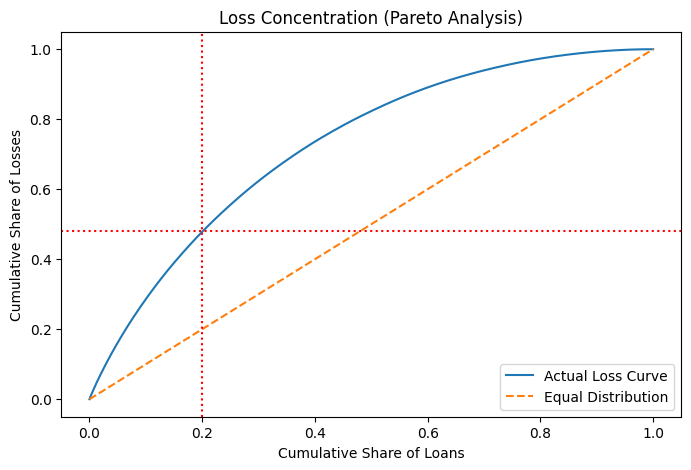

In [67]:
loss_df = df[df["net_loss"] > 0].copy()
loss_df = loss_df.sort_values("net_loss", ascending=False)
loss_df["cum_loss_share"] = loss_df["net_loss"].cumsum() / loss_df["net_loss"].sum()
loss_df["cum_loan_share"] = np.arange(1, len(loss_df)+1) / len(loss_df)

plt.figure(figsize=(8,5))
plt.plot(loss_df["cum_loan_share"], loss_df["cum_loss_share"], label="Actual Loss Curve")
plt.plot([0,1], [0,1], linestyle="--", label="Equal Distribution")
plt.axvline(0.2, linestyle=":", color="red")
plt.axhline(0.48, linestyle=":", color="red")
plt.xlabel("Cumulative Share of Loans")
plt.ylabel("Cumulative Share of Losses")
plt.title("Loss Concentration (Pareto Analysis)")
plt.legend()
plt.show()

## Objective

Analyze a large real-world lending dataset to understand:

- **default / charge-off risk patterns** (loan_status outcomes)
- **recovery and loss behavior** (recoveries vs outstanding)
- **drivers of loan performance** (grade, interest rate, income, DTI, purpose)

…and translate findings into **portfolio-level risk controls** and **pricing / policy insights**.

> Note: To handle dataset size safely in Colab, analysis uses selected columns (`usecols`) and a controlled sample (`nrows`).

## Dataset

**Source:** Lending Club — Accepted Loans (2007–2018)

This project focuses on **issued loans** to analyze:
- realized credit outcomes
- defaults and charge-offs
- recoveries and loss behavior

Rejected applications are intentionally excluded, as they do not generate
observed repayment or loss outcomes.

### Working with Large Data Safely

Given the size of the dataset (>1.5 GB), analysis is performed using a
controlled and efficient loading strategy:

- Read the full column list without loading data
- Select only relevant fields using `usecols`
- Start with a fixed-size sample (`nrows`) suitable for exploration

This approach ensures reproducibility without sacrificing analytical depth.

### Note on Censored Outcomes (Survival Bias)

Some loans in the dataset are **still active ("Current")** and do not yet have a realized final outcome.
For risk and loss analysis, **including Current loans would understate default rates** (because some will default later).

Therefore, most loss and pricing conclusions are interpreted primarily using **finalized outcomes**
(**Fully Paid / Charged Off / Default**) and are presented with this limitation in mind.

## Environment Setup

Configure display settings for working with a wide, high-column dataset.
This improves readability during inspection and validation without affecting
the underlying data.

In [68]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## Data Access & File Paths

Mount Google Drive and define reusable file paths for loading
large Lending Club datasets stored externally.

In [69]:
from google.colab import drive
drive.mount("/content/drive")

base_path = "/content/drive/MyDrive/datasets/lending_club/"
accepted_path = base_path + "accepted_2007_to_2018Q4.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Inspect Dataset Schema (Safe Load)

Before loading any data, inspect the full column list to understand
the available fields and safely select only the variables needed
for analysis.

In [70]:
all_cols = pd.read_csv(accepted_path, nrows=0).columns.tolist()
len(all_cols), all_cols[:30]   # shows count + first 30 only

(151,
 ['id',
  'member_id',
  'loan_amnt',
  'funded_amnt',
  'funded_amnt_inv',
  'term',
  'int_rate',
  'installment',
  'grade',
  'sub_grade',
  'emp_title',
  'emp_length',
  'home_ownership',
  'annual_inc',
  'verification_status',
  'issue_d',
  'loan_status',
  'pymnt_plan',
  'url',
  'desc',
  'purpose',
  'title',
  'zip_code',
  'addr_state',
  'dti',
  'delinq_2yrs',
  'earliest_cr_line',
  'fico_range_low',
  'fico_range_high',
  'inq_last_6mths'])

In [71]:
use_cols = [
    "id", "issue_d", "loan_status",
    "loan_amnt", "term", "int_rate", "installment",
    "grade", "sub_grade",
    "fico_range_low", "fico_range_high",
    "annual_inc", "dti", "emp_length", "home_ownership",
    "total_pymnt", "total_rec_prncp", "total_rec_int",
    "recoveries", "collection_recovery_fee",
    "purpose", "addr_state", "last_pymnt_d"
]
len(use_cols)

23

In [72]:
df = pd.read_csv(
    accepted_path,
    usecols=use_cols,
    nrows=500_000,
    low_memory=False
)

df.shape

(500000, 23)

In [73]:
df.head()

,id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,addr_state,dti,fico_range_low,fico_range_high,total_pymnt,total_rec_prncp,total_rec_int,recoveries,collection_recovery_fee,last_pymnt_d
0,68407277,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,675.0,679.0,4421.723917,3600.00,821.72,0.0,0.0,Jan-2019
1,68355089,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Dec-2015,Fully Paid,small_business,SD,16.06,715.0,719.0,25679.660000,24700.00,979.66,0.0,0.0,Jun-2016
2,68341763,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Dec-2015,Fully Paid,home_improvement,IL,10.78,695.0,699.0,22705.924294,20000.00,2705.92,0.0,0.0,Jun-2017
3,66310712,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Dec-2015,Current,debt_consolidation,NJ,17.06,785.0,789.0,31464.010000,19102.35,12361.66,0.0,0.0,Feb-2019
4,68476807,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Dec-2015,Fully Paid,major_purchase,PA,25.37,695.0,699.0,11740.500000,10400.00,1340.50,0.0,0.0,Jul-2016


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       500000 non-null  object 
 1   loan_amnt                499998 non-null  float64
 2   term                     499998 non-null  object 
 3   int_rate                 499998 non-null  float64
 4   installment              499998 non-null  float64
 5   grade                    499998 non-null  object 
 6   sub_grade                499998 non-null  object 
 7   emp_length               469093 non-null  object 
 8   home_ownership           499998 non-null  object 
 9   annual_inc               499998 non-null  float64
 10  issue_d                  499998 non-null  object 
 11  loan_status              499998 non-null  object 
 12  purpose                  499998 non-null  object 
 13  addr_state               499998 non-null  object 
 14  dti 

In [75]:
# Missingness (top 10)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nTop missing % columns:")
display(missing_pct.head(10))


Top missing % columns:


,0
emp_length,6.1814
last_pymnt_d,0.0818
dti,0.0436
grade,0.0004
loan_amnt,0.0004
term,0.0004
int_rate,0.0004
addr_state,0.0004
sub_grade,0.0004
installment,0.0004


In [76]:
# Duplicate loan IDs?
dup_ids = df["id"].duplicated().sum()
print("\nDuplicate id count:", dup_ids)



Duplicate id count: 0


In [77]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

,0
emp_length,6.1814
last_pymnt_d,0.0818
dti,0.0436
grade,0.0004
loan_amnt,0.0004
term,0.0004
int_rate,0.0004
addr_state,0.0004
sub_grade,0.0004
installment,0.0004


In [78]:
# Step 2 — Basic parsing (no filtering, no labels)

# 1) term: "36 months" -> 36
df["term_months"] = (
    df["term"]
    .astype("string")
    .str.extract(r"(\d+)")
    .astype("Int64")
)

# 2) parse dates
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["last_pymnt_d"] = pd.to_datetime(df["last_pymnt_d"], format="%b-%Y", errors="coerce")

# 3) FICO midpoint (representative origination score)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

# Sanity check
df[["term", "term_months", "issue_d", "last_pymnt_d", "fico_mid"]].head()

,term,term_months,issue_d,last_pymnt_d,fico_mid
0,36 months,36,2015-12-01,2019-01-01,677.0
1,36 months,36,2015-12-01,2016-06-01,717.0
2,60 months,60,2015-12-01,2017-06-01,697.0
3,60 months,60,2015-12-01,2019-02-01,787.0
4,60 months,60,2015-12-01,2016-07-01,697.0


In [79]:
#Numeric sanity checks & outlier handling

# 1) Quick numeric overview
df[["loan_amnt", "annual_inc", "dti", "int_rate"]].describe()

,loan_amnt,annual_inc,dti,int_rate
count,499998.000000,4.999980e+05,499782.000000,499998.000000
mean,15388.960556,7.718632e+04,19.245352,12.574207
std,8852.271158,7.534664e+04,12.055632,4.438228
min,1000.000000,0.000000e+00,0.000000,5.310000
25%,8500.000000,4.600000e+04,12.390000,9.170000
50%,14000.000000,6.500000e+04,18.470000,12.290000
75%,20000.000000,9.200000e+04,25.310000,15.590000
max,40000.000000,9.500000e+06,999.000000,30.990000


In [80]:
# 2) Deep dive into DTI outliers
df["dti"].describe(percentiles=[0.95, 0.99, 0.995, 0.999])

,dti
count,499782.000000
mean,19.245352
std,12.055632
min,0.000000
50%,18.470000
95%,34.620000
99%,39.130000
99.5%,40.580000
99.9%,74.925990
max,999.000000


### Outlier Handling

Certain numeric fields contain known placeholder or extreme values:

- `dti >= 100` likely represents missing or invalid ratios
- `annual_inc <= 0` is treated as invalid income

These values are set to missing (`NaN`) to prevent distortion of summary statistics.

In [81]:
# 3) Treat absurd values as missing

# DTI >= 100 is not realistic
df.loc[df["dti"] >= 100, "dti"] = np.nan

# Annual income <= 0 makes no sense
df.loc[df["annual_inc"] <= 0, "annual_inc"] = np.nan

# Sanity check after cleaning
df[["annual_inc", "dti"]].describe()

,annual_inc,dti
count,4.997890e+05,499503.000000
mean,7.721860e+04,19.112001
std,7.534585e+04,9.078488
min,1.000000e+00,0.000000
25%,4.600000e+04,12.390000
50%,6.500000e+04,18.460000
75%,9.200000e+04,25.300000
max,9.500000e+06,99.590000


In [82]:
# Step 4 — Loan outcome labeling (credit-standard)

# Remove rows with missing loan_status (very rare, but be explicit)
df = df[df["loan_status"].notna()].copy()

# Final outcomes only (closed credit cycle)
final_statuses = ["Fully Paid", "Charged Off", "Default"]

df["is_final"] = df["loan_status"].isin(final_statuses)
df["is_default"] = df["loan_status"].isin(["Charged Off", "Default"])
df["is_active"] = ~df["is_final"]

df[["loan_status", "is_final", "is_default", "is_active"]].value_counts()

,,,,count
loan_status,is_final,is_default,is_active,
Fully Paid,True,False,False,312340
Current,False,False,True,104240
Charged Off,True,True,False,78824
Late (31-120 days),False,False,True,2977
In Grace Period,False,False,True,1046
Late (16-30 days),False,False,True,567
Default,True,True,False,4


### Status Flags

Boolean flags are created to simplify filtering and aggregation:

- `is_final` → Loan has reached a terminal state
- `is_default` → Loan resulted in loss (charge-off or default)
- `is_active` → Loan still in progress

These flags allow flexible slicing without permanently dropping records.

### Credit Lifecycle Note

Loan status values represent different stages of the credit lifecycle:

- **Fully Paid** → Loan closed successfully
- **Charged Off** → Loan written off after prolonged delinquency
- **Default** → Loan defaulted and closed
- **Current / Late / Grace Period** → Active loans without final outcomes

For **portfolio composition**, all loans are retained.  
For **default and recovery analysis**, only *finalized loans* are used.

In [83]:
df.groupby("loan_status")[["is_final", "is_default", "is_active"]].mean()

,is_final,is_default,is_active
loan_status,,,
Charged Off,1.0,1.0,0.0
Current,0.0,0.0,1.0
Default,1.0,1.0,0.0
Fully Paid,1.0,0.0,0.0
In Grace Period,0.0,0.0,1.0
Late (16-30 days),0.0,0.0,1.0
Late (31-120 days),0.0,0.0,1.0


In [84]:
# Re-check structure after cleaning & parsing
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499998 entries, 0 to 499999
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   id                       499998 non-null  object        
 1   loan_amnt                499998 non-null  float64       
 2   term                     499998 non-null  object        
 3   int_rate                 499998 non-null  float64       
 4   installment              499998 non-null  float64       
 5   grade                    499998 non-null  object        
 6   sub_grade                499998 non-null  object        
 7   emp_length               469093 non-null  object        
 8   home_ownership           499998 non-null  object        
 9   annual_inc               499789 non-null  float64       
 10  issue_d                  499998 non-null  datetime64[ns]
 11  loan_status              499998 non-null  object        
 12  purpose              

### End of Data Preparation

At this stage, the dataset is:
- audited for structure and quality
- cleaned for obvious errors and placeholders
- enriched with derived risk and recovery metrics

The next section will focus exclusively on **analytical questions**.

## SECTION 1 — Portfolio Overview

### Q1. What is the overall loan outcome distribution?

Analyze the distribution of loans across different outcome states to establish a
baseline view of portfolio health.

Specifically, quantify how many loans fall into each of the following categories:
- Fully Paid
- Charged Off
- Default / Late
- Current

This provides the foundational context for all subsequent risk and recovery analysis.

In [85]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,312340
Current,104240
Charged Off,78824
Late (31-120 days),2977
In Grace Period,1046
Late (16-30 days),567
Default,4


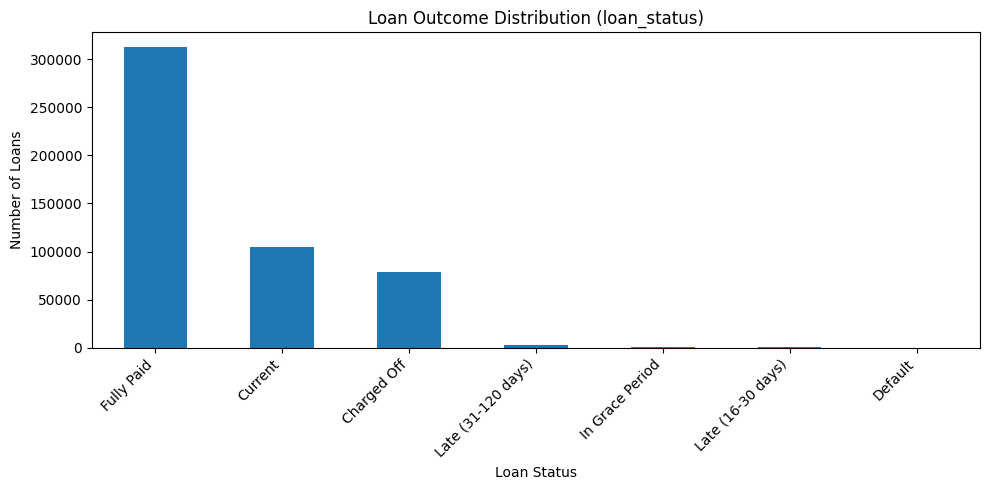

In [86]:
import matplotlib.pyplot as plt

status_counts = df["loan_status"].value_counts()

plt.figure(figsize=(10,5))
status_counts.plot(kind="bar")
plt.title("Loan Outcome Distribution (loan_status)")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## SECTION 2 — Loan Structure & Pricing Risk

## Q2. How does loan performance vary by loan term?

Analyze loan outcomes across **36-month vs 60-month** tenors to evaluate whether
longer-tenure loans carry structurally higher credit risk.

Key aspects to examine:
- **Default / Charge-off rate** by loan term  
- **Recovery behavior** on charged-off loans  
- **Net loss exposure** across tenors  

**Purpose:**  
Assess whether extended loan duration increases portfolio risk and
whether higher yields on long-tenure loans adequately compensate for
incremental default and recovery risk.

In [87]:
#Default / Charge-off rate by loan term

default_rate_by_term = (
    df.groupby("term_months")
      .agg(
          total_loans = ("id", "count"),
          default_rate = ("is_default", "mean")
      )
      .reset_index()
)

default_rate_by_term

,term_months,total_loans,default_rate
0,36,338269,0.129976
1,60,161729,0.215552


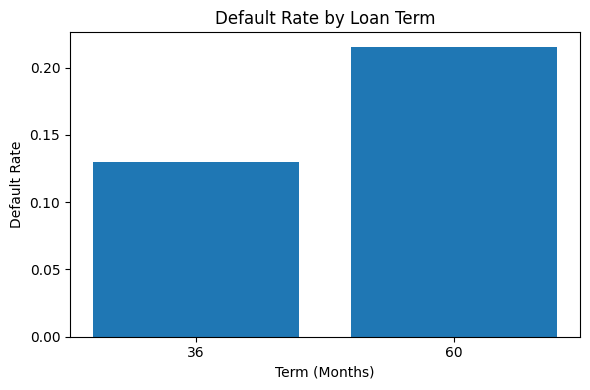

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(default_rate_by_term["term_months"].astype(str), default_rate_by_term["default_rate"])
plt.title("Default Rate by Loan Term")
plt.xlabel("Term (Months)")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

In [89]:
#Recovery behavior on charged-off loans

charged_off = df[df["loan_status"] == "Charged Off"].copy()

recovery_by_term = (
    charged_off.groupby("term_months")
               .agg(
                   charged_off_loans = ("id", "count"),
                   avg_recovery = ("total_pymnt", "mean"),
                   total_recovery = ("total_pymnt", "sum")
               )
               .reset_index()
)

recovery_by_term


,term_months,charged_off_loans,avg_recovery,total_recovery
0,36,43966,7582.508648,3.333726e+08
1,60,34858,10528.983256,3.670193e+08


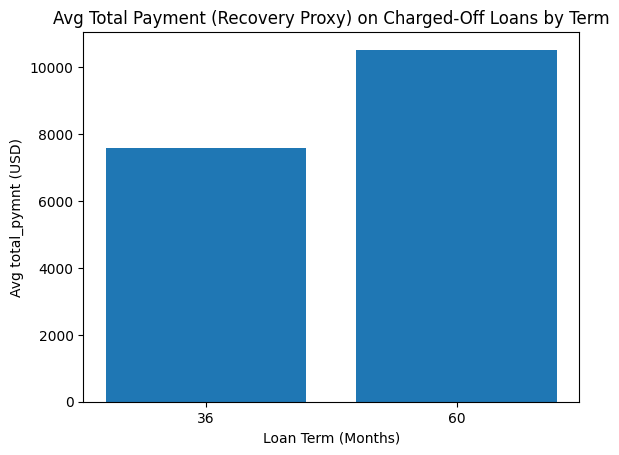

In [90]:
plt.figure()
plt.bar(
    recovery_by_term["term_months"].astype(str),
    recovery_by_term["avg_recovery"]
)
plt.title("Avg Total Payment (Recovery Proxy) on Charged-Off Loans by Term")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Avg total_pymnt (USD)")
plt.show()

In [91]:
#Net loss exposure across tenors

df["net_loss"] = df["loan_amnt"] - df["total_pymnt"]

loss_by_term = (
    df[df["is_default"]]
      .groupby("term_months")
      .agg(
          defaulted_loans = ("id", "count"),
          total_net_loss = ("net_loss", "sum"),
          avg_loss_per_default = ("net_loss", "mean")
      )
      .reset_index()
)

loss_by_term

,term_months,defaulted_loans,total_net_loss,avg_loss_per_default
0,36,43967,2.172828e+08,4941.952887
1,60,34861,3.267870e+08,9374.000016


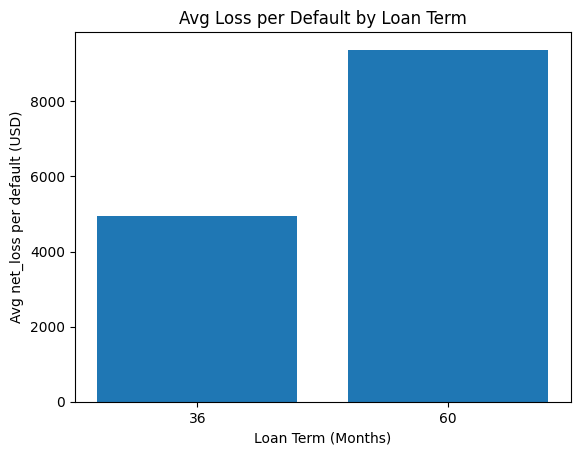

In [92]:
plt.figure()
plt.bar(
    loss_by_term["term_months"].astype(str),
    loss_by_term["avg_loss_per_default"]
)
plt.title("Avg Loss per Default by Loan Term")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Avg net_loss per default (USD)")
plt.show()

### Key Insights — Loan Term Risk (36 vs 60 Months)

- **60-month loans are structurally riskier than 36-month loans.**
  - Default / charge-off rate for 60-month loans is **~21.6%**, compared to **~13.0%** for 36-month loans.
  - This represents a **~66% higher probability of default** for longer-tenor loans.

- **Higher recoveries on 60-month loans do not offset higher risk.**
  - Although average recovery per charged-off 60-month loan is higher, this is driven by larger original loan amounts, not better recovery efficiency.

- **Loss severity is materially worse for longer tenors.**
  - Average net loss per defaulted loan:
    - **36 months:** ~₹4,900  
    - **60 months:** ~₹9,400
  - This implies nearly **2× loss severity** when a 60-month loan defaults.

- **Portfolio-level impact:**
  - Despite fewer defaults in absolute count, 60-month loans generate **significantly higher total net losses** than 36-month loans.

### Business Implication

Longer-tenor loans increase portfolio risk through both:
- **Higher default frequency**
- **Higher loss severity per default**

This indicates that interest rate premiums on 60-month loans are **insufficient to compensate for incremental credit risk**, justifying:
- tighter underwriting standards,
- higher risk-adjusted pricing, or
- explicit exposure limits on long-tenor loans.

## Q3. What is the average interest rate by loan outcome?

### Business Question

How does the **average interest rate** differ across loan outcomes, specifically:

- **Fully Paid loans**
- **Charged Off loans**
- Other delinquent / defaulted outcomes

### Why this matters

In a well-functioning credit portfolio, **higher-risk borrowers should be priced
with higher interest rates** to compensate for expected losses.

If charged-off loans do **not** carry meaningfully higher interest rates than
fully paid loans, it suggests:

- ineffective risk-based pricing,
- misclassification of borrower risk at origination, or
- aggressive growth at the cost of credit quality.

### Analytical Focus

This analysis compares:
- average interest rates across loan outcome categories,
- the pricing gap between successful and failed loans,
- and whether interest rate differentiation aligns with realized credit risk.

The objective is to evaluate whether **pricing actually reflects risk**, not
just whether defaults exist.

In [93]:
fully_repaid_avg_interest = round(df[df['loan_status']=='Fully Paid']['int_rate'].mean(),2)

charged_off_loans_avg_interest = round(df[df['loan_status']=='Charged Off']['int_rate'].mean(),2)

#default number is just 4
default_loans_avg_interest = round(df[df['loan_status']=='Default']['int_rate'].mean(),2)

#Active Loans Avg Interest - for comparison
active_loans_avg_interest = round(df[df['is_active']== True]['int_rate'].mean(),2)

avg_interest_snapshot = pd.DataFrame({
    "loan_status": [
        "Fully Paid",
        "Charged Off",
        "Default",
        "Active"
    ],
    "avg_interest_rate": [
        fully_repaid_avg_interest,
        charged_off_loans_avg_interest,
        default_loans_avg_interest,
        active_loans_avg_interest
    ]
})
avg_interest_snapshot

,loan_status,avg_interest_rate
0,Fully Paid,11.77
1,Charged Off,15.00
2,Default,19.74
3,Active,13.14


### Key Insight

Loans that eventually charge off carry a **meaningfully higher average interest rate**
than fully paid loans, indicating that **risk-based pricing is applied at origination**.

However, the higher interest charged on risky borrowers is **not sufficient to offset
realized credit losses**, as these loans still end in charge-off.

This suggests a gap between:
- **risk recognition** (higher rates for riskier borrowers), and
- **risk compensation** (pricing not high enough to cover default losses).

*Note: The “Default” category has very few observations(4) and is included for completeness only.*

## Q4. Does higher interest rate actually reduce losses?

### Business Question

Does charging a higher interest rate actually compensate for higher credit risk,
or do high-rate loans still destroy disproportionate value?

### What we test

Loans are grouped into **interest rate buckets**, and for each bucket we measure:

- **Default rate** — how often loans fail
- **Loss rate** — net economic loss relative to loan amount
- **Net recovery** — how much money is actually recovered after default

### Why this matters

This question answers the core banking dilemma:

> **“Are we being paid enough for the risk we are taking?”**

If higher interest rates do **not** reduce loss severity,
then pricing alone is insufficient and **credit policy must change**.

In [94]:
# Flags for convenience
df["is_bad_final"] = df["loan_status"].isin(["Charged Off", "Default"])
df["is_good_final"] = df["loan_status"].eq("Fully Paid")

df_final = df[df["loan_status"].isin(["Fully Paid", "Charged Off", "Default"])].copy()

bins = [0, 8, 10, 12, 14, 16, 18, 100]
labels = ["<=8", "8-10", "10-12", "12-14", "14-16", "16-18", "18+"]

df_final["int_rate_bucket"] = pd.cut(df_final["int_rate"], bins=bins, labels=labels, right=True)

int_rate_buckets = df_final.groupby('int_rate_bucket',observed=True).agg(
    default_rate = ('is_bad_final','mean'),
    total_loan_amount = ('loan_amnt','sum'),
    total_net_loss = ('net_loss','sum'),
    net_recovery = ('recoveries','sum')
).reset_index()

int_rate_buckets['loss_rate'] = round(int_rate_buckets['total_net_loss'] / int_rate_buckets['total_loan_amount'],4)
int_rate_buckets

,int_rate_bucket,default_rate,total_loan_amount,total_net_loss,net_recovery,loss_rate
0,<=8,0.055331,1.065676e+09,-6.786709e+07,3652715.80,-0.0637
1,8-10,0.111926,9.008854e+08,-5.752212e+07,7006518.36,-0.0639
2,10-12,0.155319,6.858902e+08,-3.958431e+07,8066389.72,-0.0577
3,12-14,0.217097,1.190058e+09,-5.155008e+07,21294098.19,-0.0433
4,14-16,0.269148,5.210944e+08,-1.203923e+07,11488999.37,-0.0231
5,16-18,0.335613,6.033589e+08,2.277955e+06,18038150.69,0.0038
6,18+,0.437490,7.702212e+08,5.141565e+07,31385058.49,0.0668


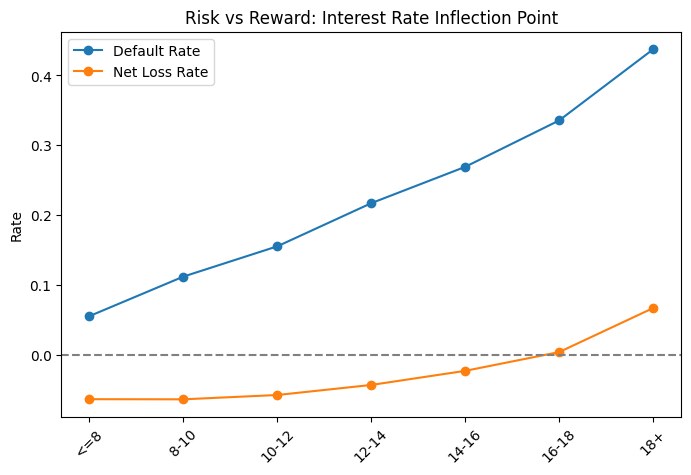

In [95]:
plt.figure(figsize=(8,5))
plt.plot(int_rate_buckets["int_rate_bucket"], int_rate_buckets["default_rate"], marker="o", label="Default Rate")
plt.plot(int_rate_buckets["int_rate_bucket"], int_rate_buckets["loss_rate"], marker="o", label="Net Loss Rate")
plt.axhline(0, linestyle="--", color="gray")
plt.xticks(rotation=45)
plt.title("Risk vs Reward: Interest Rate Inflection Point")
plt.ylabel("Rate")
plt.legend()
plt.show()

###  Key Insight

Loan pricing shows a **non-linear relationship** between interest rates, default risk,
and economic outcomes.

Key observations:

- Default rates increase sharply with higher interest rates, rising from ~5% in the
  lowest bucket (≤8%) to over 43% in the highest bucket (18%+).
- Despite higher default risk, loans priced up to ~14% interest remain **net profitable
  at the portfolio level**, as interest income offsets losses.
- The **14–16% range emerges as a danger zone**:
  - High default rates
  - Marginal profitability
  - Poor risk-adjusted returns
- Break-even economics are reached only beyond ~16% interest.
- At the highest interest band (18%+), **net portfolio losses reappear**, indicating that
  extreme risk cannot be fully priced away.

Conclusion:

Higher interest rates **do not eliminate risk** — they only delay economic damage.
Aggressive pricing compensates for moderate risk, but **fails against structurally
high-risk borrowers**, where defaults overwhelm interest income.

This suggests that:
- Pricing alone is insufficient as a risk control
- Certain risk segments should be restricted or rejected rather than repriced

## Q5. Are some credit grades underpriced for their risk?

### Question

Are certain **credit grades / sub-grades** being priced too cheaply relative to the
risk they actually carry?

### What we analyze

For each **Grade / Sub-grade**, we examine:

- **Default rate** — how frequently loans end in Charged Off or Default
- **Average interest rate** — how the lender prices perceived risk
- **Loss severity** — economic loss when defaults occur

### Purpose

Identify **pricing misalignment by credit quality**, such as:

- Grades with **high default rates but insufficient interest pricing**
- Grades that generate **large losses despite higher rates**
- Grades where **risk and pricing appear well aligned**

This helps answer a core credit question:

> Are we being adequately compensated for the risk taken at each credit grade?

In [96]:
grade_analysis = (
    df.groupby("grade")
      .agg(
          total_loans = ("id", "count"),
          defaults = ("is_default", "sum"),
          default_rate = ("is_default", "mean"),
          avg_int_rate = ("int_rate", "mean"),
          total_net_loss = ("net_loss", "sum")
      )
      .reset_index()
)

grade_analysis["loss_severity_per_default"] = round(
    grade_analysis["total_net_loss"] / grade_analysis["defaults"],2
)

grade_analysis

,grade,total_loans,defaults,default_rate,avg_int_rate,total_net_loss,loss_severity_per_default
0,A,92870,4216,0.045397,6.899765,8.954246e+07,21238.72
1,B,141336,14525,0.102769,10.126523,1.268347e+08,8732.17
2,C,141680,24398,0.172205,13.428662,1.274311e+08,5223.01
3,D,73872,18114,0.245208,17.096166,7.269511e+07,4013.20
4,E,37663,12260,0.325518,19.701466,2.455971e+07,2003.24
5,F,10317,4274,0.414268,23.894662,1.123723e+07,2629.21
6,G,2260,1041,0.460619,26.998460,3.258180e+06,3129.86


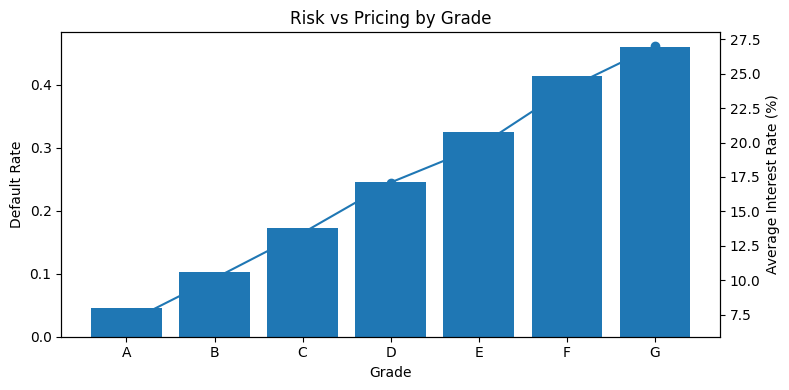

In [97]:
import matplotlib.pyplot as plt

x = grade_analysis["grade"].astype(str)
default_rate = grade_analysis["default_rate"]
avg_int = grade_analysis["avg_int_rate"]

fig, ax1 = plt.subplots(figsize=(8,4))

ax1.bar(x, default_rate)
ax1.set_xlabel("Grade")
ax1.set_ylabel("Default Rate")
ax1.set_title("Risk vs Pricing by Grade")

ax2 = ax1.twinx()
ax2.plot(x, avg_int, marker="o")
ax2.set_ylabel("Average Interest Rate (%)")

fig.tight_layout()
plt.show()

### Q5 Insights — Credit Grade Pricing vs Risk

Loan performance deteriorates steadily from Grade A to Grade G, as expected, but pricing does not fully compensate for the rising risk.

- **Default rates increase monotonically** from ~4.5% (Grade A) to ~46% (Grade G), confirming that credit grades correctly rank borrower risk.
- **Average interest rates rise with grade**, but the increase is **not proportional to the jump in default risk**, especially in mid-grades.
- **Grades B and C show clear underpricing signals**:
  - Default rates nearly double from B to C,
  - Yet average interest rates increase only modestly.
- **Loss severity per default declines from A to E**, indicating that:
  - High-grade borrowers default less often but tend to default on larger balances.
  - Mid-grade borrowers default more frequently, driving portfolio-level losses.
- **High-risk grades (F and G)** are priced aggressively but still exhibit:
  - Very high default rates,
  - Meaningful loss severity,
  suggesting that pricing alone cannot offset structural credit risk at the bottom of the spectrum.

**Conclusion:**  
While credit grades effectively rank risk, **pricing in Grades B–D appears insufficient relative to default probability**, indicating potential underpricing in the core of the portfolio rather than at the extremes.

## SECTION 3 — Economic Loss & Value Destruction

### Q6. Where does the portfolio actually lose money?

This question identifies **where real economic damage occurs**, not just where defaults happen.

We define **economic loss** using:
- **Charged-off loans** only (realized failures)
- **Recoveries** (cash recovered post charge-off)
- **Interest earned** as a proxy for income

Net loss is measured as:
> Loan Amount − Total Payments Received

The analysis focuses on loss concentration across:
- **Credit Grade**
- **Loan Term (36 vs 60 months)**
- **Loan Purpose**

#### Purpose
Move beyond default counts and rates to understand:
- Which segments generate **actual financial losses**
- Where pricing and underwriting fail to compensate for risk
- Which parts of the portfolio require tightening, repricing, or exclusion

In [98]:
loan_purpose_analysis = (
    df.groupby("purpose")
      .agg(
          total_loans = ("id", "count"),
          defaults = ("is_default", "sum"),
          default_rate = ("is_default", "mean"),
          avg_int_rate = ("int_rate", "mean"),
          total_net_loss = ("net_loss", "sum")
      )
      .reset_index()
)

loan_purpose_analysis["loss_severity_per_default"] = round(
    loan_purpose_analysis["total_net_loss"] / loan_purpose_analysis["defaults"],2
)
loan_purpose_analysis

,purpose,total_loans,defaults,default_rate,avg_int_rate,total_net_loss,loss_severity_per_default
0,car,4488,539,0.120098,11.797451,4.375933e+06,8118.61
1,credit_card,119788,15603,0.130255,11.028442,8.782798e+07,5628.92
2,debt_consolidation,290241,49713,0.171282,13.040725,2.388617e+08,4804.81
3,educational,1,0,0.000000,11.530000,-2.410400e+02,-inf
4,home_improvement,31064,4309,0.138714,12.266792,3.642682e+07,8453.66
5,house,2632,382,0.145137,14.597793,9.452996e+06,24746.06
6,major_purchase,9874,1418,0.143609,12.342497,1.940286e+07,13683.26
7,medical,5220,837,0.160345,13.463542,6.442555e+06,7697.20
8,moving,2959,564,0.190605,14.986999,2.353972e+06,4173.71
9,other,26312,4045,0.153732,13.739127,3.868086e+07,9562.63


### Key Insights — Where the Portfolio Actually Loses Money

This analysis shifts focus from **default counts** to **real economic damage**, measured using net loss after recoveries and interest earned.

**1. Loss concentration is highly uneven across credit grades**
- Lower grades (**C → G**) contribute a **disproportionately large share of total portfolio losses**, even when loan volumes decline.
- Higher grades (A, B) show:
  - Lower default rates
  - Negative or near-zero net loss (interest income outweighs defaults)
- Loss severity per default *declines* as grades worsen, indicating that:
  - Risk is priced higher,
  - But not sufficiently to fully offset higher default frequency in lower grades.

**2. Longer-tenor loans amplify economic loss**
- 60-month loans exhibit:
  - Higher default rates
  - Higher cumulative net losses
- Extended tenor increases exposure duration, compounding loss even when recoveries exist.
- This confirms that **tenor is a structural risk amplifier**, not just a pricing variable.

**3. Loan purpose reveals structural loss pockets**
- **Debt consolidation** and **credit card refinancing** drive the largest absolute losses due to sheer volume.
- **Small business**, **house**, and certain discretionary purposes show:
  - High default rates
  - High loss severity per default
- Some low-volume purposes show undefined loss severity (zero defaults in sample), and are excluded from policy conclusions.

**4. Recoveries reduce loss but do not neutralize risk**
- Recoveries meaningfully offset losses in higher-interest and lower-grade segments.
- However, recoveries plateau while default frequency rises, causing net loss to turn positive in high-risk buckets.

### Bottom Line

Portfolio losses are not driven by *where defaults happen most*, but by:
- **Where defaults scale**, and
- **Where pricing and recoveries fail to fully compensate risk**.

Loss control requires:
- Tighter policies for lower grades and longer tenors
- Selective restriction of structurally loss-heavy loan purposes
- Pricing rules that reflect *economic loss*, not just default probability

## SECTION 4 — Borrower Risk Drivers

### Q7. Which borrower attributes drive default the most?

This section evaluates **borrower-level characteristics** to identify which attributes have the strongest relationship with loan default.

The analysis focuses on the following underwriting variables:

- **Debt-to-Income (DTI) ratio**
- **Annual income**
- **Employment length**
- **Home ownership status**

For each attribute, loans are grouped into meaningful buckets and evaluated on:
- **Default rate**
- **Loss contribution (where applicable)**

### Purpose

The objective is to **separate true risk signals from weak or noisy indicators**, and assess which borrower attributes should meaningfully influence:
- approval decisions,
- pricing adjustments,
- or hard policy cutoffs.

This moves the analysis from portfolio aggregation to **borrower-level risk drivers**, providing insight into how well current underwriting variables explain observed default behavior.

In [99]:
#DTI Analysis

bins = [0, 10, 20, 30, 40, 100]
labels = ["< 10%", "10% – 20%", "20% – 30%", "30% – 40%", "40%+"]

df["dti_bucket"] = pd.cut(df["dti"], bins=bins, labels=labels, right=True)

dti_analysis = (
    df.groupby("dti_bucket",observed=True)
      .agg(
          total_loans = ("id", "count"),
          defaults = ("is_default", "sum"),
          default_rate = ("is_default", "mean"),
          avg_int_rate = ("int_rate", "mean"),
          total_net_loss = ("net_loss", "sum")
      )
      .reset_index()
)

dti_analysis["loss_severity_per_default"] = round(
    dti_analysis["total_net_loss"] / dti_analysis["defaults"],2
)
dti_analysis

,dti_bucket,total_loans,defaults,default_rate,avg_int_rate,total_net_loss,loss_severity_per_default
0,< 10%,82616,9488,0.114845,11.513276,8.164276e+07,8604.84
1,10% – 20%,198213,27815,0.140329,12.070029,1.412405e+08,5077.85
2,20% – 30%,154893,27633,0.178401,12.979362,1.325697e+08,4797.51
3,30% – 40%,61223,13749,0.224572,14.532233,6.835969e+07,4971.98
4,40%+,2304,98,0.042535,14.368576,2.529133e+07,258074.84


The 40%+ DTI bucket has a small sample size and reflects exception-based approvals. While default frequency is low, loss severity per default is materially higher, indicating concentrated tail risk rather than mass retail risk.

In [100]:
#Annual Income Analysis

bins = [0, 40000, 60000, 80000, 120000, 100000000000]
labels = ["< $40k", "$40k – $60k", "$60k – $80k", "$80k – $120k", "$120k+"]

df["inc_bucket"] = pd.cut(df["annual_inc"], bins=bins, labels=labels, right=True)

income_analysis = (
    df.groupby("inc_bucket",observed=True)
      .agg(
          total_loans = ("id", "count"),
          defaults = ("is_default", "sum"),
          default_rate = ("is_default", "mean"),
          avg_int_rate = ("int_rate", "mean"),
          total_net_loss = ("net_loss", "sum")
      )
      .reset_index()
)

income_analysis["loss_severity_per_default"] = round(
    income_analysis["total_net_loss"] / income_analysis["defaults"],2
)
income_analysis

,inc_bucket,total_loans,defaults,default_rate,avg_int_rate,total_net_loss,loss_severity_per_default
0,< $40k,90052,16882,0.187469,13.531130,6.806376e+07,4031.74
1,$40k – $60k,137054,23864,0.174121,12.941433,1.098643e+08,4603.77
2,$60k – $80k,107238,16863,0.157248,12.475760,9.726434e+07,5767.91
3,$80k – $120k,107477,14674,0.136532,12.000029,1.032347e+08,7035.21
4,$120k+,57968,6532,0.112683,11.460290,7.479902e+07,11451.17


Higher income is associated with lower default frequency, but not necessarily lower economic risk. High-income segments exhibit lower default rates but significantly higher loss severity per default, driven by larger loan amounts and exposure concentration.

In [101]:
# Employment Length Analysis
df["emp_length_numeric"] = (
    df["emp_length"]
      .astype("string")
      .str.strip()
      .replace({
          "< 1 year": "0",
          "10+ years": "10"
      })
      .str.extract(r"(\d+)", expand=False)
      .astype("float")
)
bins = [-0.1, 0, 3, 5, 9.999999, 100]
labels = ["< 1 year", "1–3 years", "3–5 years", "5–10 years", "10+ years"]

df["emp_len_bucket"] = pd.cut(
    df["emp_length_numeric"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

emp_length_analysis = (
    df.groupby("emp_len_bucket", observed=True)
      .agg(
          total_loans=("id", "count"),
          defaults=("is_default", "sum"),
          default_rate=("is_default", "mean"),
          avg_int_rate=("int_rate", "mean"),
          total_net_loss=("net_loss", "sum")
      )
      .reset_index()

)

emp_length_analysis["loss_severity_per_default"] = (
    emp_length_analysis["total_net_loss"] / emp_length_analysis["defaults"]
)

emp_length_analysis

,emp_len_bucket,total_loans,defaults,default_rate,avg_int_rate,total_net_loss,loss_severity_per_default
0,< 1 year,39655,6507,0.164090,12.640056,2.777167e+07,4267.968123
1,1–3 years,117779,18663,0.158458,12.635831,1.170479e+08,6271.655708
2,3–5 years,59414,9366,0.157640,12.614944,6.165777e+07,6583.148791
3,5–10 years,84672,13768,0.162604,12.631935,5.802928e+07,4214.793679
4,10+ years,167573,24565,0.146593,12.460393,1.454799e+08,5922.241446


**Employment Length vs Default Risk**

Employment length shows a weak and non-monotonic relationship with default risk. Default rates remain clustered in a narrow band (~15–16%) across most tenure buckets, with only a modest improvement for borrowers with 10+ years of employment.

Loss severity per default is higher in mid-tenure segments (1–5 years), while both very short tenure (<1 year) and long tenure (5–10 years, 10+ years) show lower severity on average.

**Conclusion:** Employment length is a secondary risk indicator. It helps marginally at the extremes (very short vs very long tenure) but does not provide strong discriminatory power on its own and should not be used as a primary underwriting cutoff.

In [102]:
#Home Ownership Analysis

home_own_analysis = (
    df.groupby("home_ownership", observed=True)
      .agg(
          total_loans=("id", "count"),
          defaults=("is_default", "sum"),
          default_rate=("is_default", "mean"),
          avg_int_rate=("int_rate", "mean"),
          total_net_loss=("net_loss", "sum")
      )
      .reset_index()

)

home_own_analysis["loss_severity_per_default"] = (
    home_own_analysis["total_net_loss"] / home_own_analysis["defaults"]
)

home_own_analysis

,home_ownership,total_loans,defaults,default_rate,avg_int_rate,total_net_loss,loss_severity_per_default
0,ANY,4,0,0.000000,16.637500,-1.366950e+04,-inf
1,MORTGAGE,245638,33112,0.134800,12.272332,1.959777e+08,5918.630683
2,OWN,56052,8863,0.158121,12.588634,6.193231e+07,6987.736392
3,RENT,198304,36853,0.185841,12.943977,1.976621e+08,5363.529171


**Home Ownership vs Default Risk**

Home ownership status shows a clear gradient in default risk. Renters exhibit the highest default rate, followed by borrowers who own their homes outright, while borrowers with mortgages perform best.

Despite lower default frequency, mortgage holders still contribute materially to total losses due to larger loan volumes, though loss severity per default remains moderate. Renters combine both elevated default rates and high aggregate losses, making them the most structurally risky segment.

The `ANY` category is immaterial due to negligible sample size and should be excluded from policy inference.

**Conclusion:** Home ownership is a meaningful underwriting signal. Renters represent higher behavioral and income volatility risk, while mortgage holders demonstrate stronger repayment discipline, even after controlling for interest rates.

### Key Insight — Borrower-Level Default Drivers

Borrower risk is primarily driven by **debt burden and cash-flow stress**, not by demographic stability proxies.

- **DTI is the strongest and most monotonic predictor of default**: default rates rise steadily from sub-10% DTI to the 30–40% band, confirming leverage as the dominant risk driver. Extremely high DTI (>40%) represents rare, exception-based approvals with low frequency but **severe tail losses**.
- **Annual income shows an inverse relationship with default probability**, but higher-income borrowers exhibit **larger loss severity per default**, indicating exposure is driven by loan size rather than frequency.
- **Employment length has limited marginal predictive power beyond the first year**: default rates stabilize after early tenure, suggesting diminishing underwriting value once basic employment continuity is established.
- **Home ownership is a behavioral risk signal**: renters exhibit the highest default rates, while mortgage holders show more stable performance, though loss severity remains comparable.

Overall, **DTI dominates underwriting signal**, income primarily affects **loss severity**, and employment length and home ownership act as **secondary stabilizers rather than primary risk drivers**.


## SECTION 5 — Segment-Level Risk & Concentration

### Q8. Does loan purpose matter for risk and loss?

This analysis evaluates whether **loan purpose materially affects credit risk and economic loss**.

For each loan purpose, we analyze:
- **Default rate** — frequency of failure
- **Loss severity** — economic loss per default
- **Total portfolio loss contribution**

The goal is to identify whether certain purposes are:
- structurally higher risk,
- inadequately priced for their risk,
- or suitable candidates for tighter / looser credit policy.

👉 **Purpose:** Derive policy-level insights on which loan purposes should be restricted, repriced, or encouraged.

In [103]:
loan_purpose_analysis

,purpose,total_loans,defaults,default_rate,avg_int_rate,total_net_loss,loss_severity_per_default
0,car,4488,539,0.120098,11.797451,4.375933e+06,8118.61
1,credit_card,119788,15603,0.130255,11.028442,8.782798e+07,5628.92
2,debt_consolidation,290241,49713,0.171282,13.040725,2.388617e+08,4804.81
3,educational,1,0,0.000000,11.530000,-2.410400e+02,-inf
4,home_improvement,31064,4309,0.138714,12.266792,3.642682e+07,8453.66
5,house,2632,382,0.145137,14.597793,9.452996e+06,24746.06
6,major_purchase,9874,1418,0.143609,12.342497,1.940286e+07,13683.26
7,medical,5220,837,0.160345,13.463542,6.442555e+06,7697.20
8,moving,2959,564,0.190605,14.986999,2.353972e+06,4173.71
9,other,26312,4045,0.153732,13.739127,3.868086e+07,9562.63


### Key Insights — Does Loan Purpose Matter for Risk and Loss?

Loan purpose materially affects both **default behavior** and **loss severity**, indicating that some purposes represent **structural credit risk** rather than volume-driven risk.

**1. Debt consolidation drives the largest absolute losses, but not the worst structural risk**
- Debt consolidation contributes the **highest total net loss** due to sheer loan volume.
- Default rate (~17%) and loss severity per default are **moderate relative to riskier purposes**.
- This suggests a **scale problem**, not a fundamentally flawed product.
- Policy implication: focus on **pricing and underwriting refinement**, not outright restriction.

**2. Small business and house loans are structurally high-risk**
- Small business and house loans exhibit:
  - High default rates (~21–22%)
  - High loss severity per default
- Losses are driven by **poor recoverability and volatile cash flows**, not loan volume.
- These purposes behave closer to **quasi-equity risk** than consumer credit.
- Policy implication: tighter eligibility, higher pricing floors, or selective exclusion.

**3. Discretionary and shock-driven purposes show elevated risk**
- Medical, moving, and “other” purposes show:
  - Above-average default rates
  - Meaningful loss severity
- These loans are often associated with **financial stress events**, not planned borrowing.
- Policy implication: conservative caps, stricter DTI thresholds, or shorter tenors.

**4. Major purchase and home improvement loans show mixed risk**
- Default rates are moderate, but loss severity can be high.
- Indicates **asset-backed intent**, but weak collateral recovery in practice.
- Policy implication: allow selectively with stronger income and credit filters.

**5. Very low-volume purposes are statistically unreliable**
- Categories such as educational and wedding loans have negligible sample sizes.
- Extreme or undefined loss metrics are artifacts of small samples.
- Policy implication: exclude from decision-making or pool into an “Other” category.

### Bottom Line

Loan purpose is a **meaningful underwriting signal**, not just a descriptive attribute.

- Some purposes (e.g., debt consolidation) require **better pricing discipline**
- Others (e.g., small business, house, stress-driven purposes) require **structural tightening**
- Treating all purposes uniformly leads to hidden loss concentration

Effective credit policy should **differentiate by purpose**, not merely by borrower credit score.

### Q9. Is Risk Concentrated or Diversified? (Pareto Test)

This analysis tests whether portfolio losses are driven by a **small, identifiable subset of loans** or are **broadly distributed across the book**.

The Pareto (80/20) framework is used to examine:
- What % of total economic loss is generated by the **top 20% of loans**
- Whether losses are concentrated by:
  - **Credit Grade**
  - **Loan Purpose**
  - **Loan Term (36 vs 60 months)**

#### Methodology
- Rank loans by **net loss contribution**
- Compute cumulative loss share vs cumulative loan share
- Repeat the concentration analysis across:
  - Grade segments
  - Purpose segments
  - Tenor segments

#### Purpose
Determine whether portfolio risk can be reduced through:
- **Surgical fixes** (targeted policy, pricing, or exclusion rules), or
- **System-wide tightening** (broad credit contraction or repricing)

This distinction is critical for designing efficient and scalable credit policy interventions.

In [104]:
#Overall

loss_df = df[df["net_loss"] > 0].copy()
loss_df_sorted = loss_df.sort_values("net_loss", ascending=False)

top_n = int(0.20 * len(loss_df_sorted))
top_20pct = loss_df_sorted.head(top_n)

pareto_share = round(
    top_20pct["net_loss"].sum() / loss_df_sorted["net_loss"].sum(),
    2
)

pareto_share

np.float64(0.48)

In [105]:
# By Grade

top_20pct_grade = round(
    top_20pct.groupby('grade')['net_loss'].sum() / loss_df_sorted["net_loss"].sum(),
    2)
top_20pct_grade

,net_loss
grade,
A,0.07
B,0.12
C,0.13
D,0.08
E,0.05
F,0.02
G,0.01


In [106]:
# By Loan Purpose

top_20pct_purpose = round(
    top_20pct.groupby('purpose')['net_loss'].sum() / loss_df_sorted["net_loss"].sum(),
    2)
top_20pct_purpose

,net_loss
purpose,
car,0.00
credit_card,0.10
debt_consolidation,0.29
home_improvement,0.04
house,0.01
major_purchase,0.01
medical,0.00
moving,0.00
other,0.02


In [107]:
# By Term

top_20pct_term = round(
    top_20pct.groupby('term_months')['net_loss'].sum() / loss_df_sorted["net_loss"].sum(),
    2)
top_20pct_term

,net_loss
term_months,
36,0.17
60,0.31


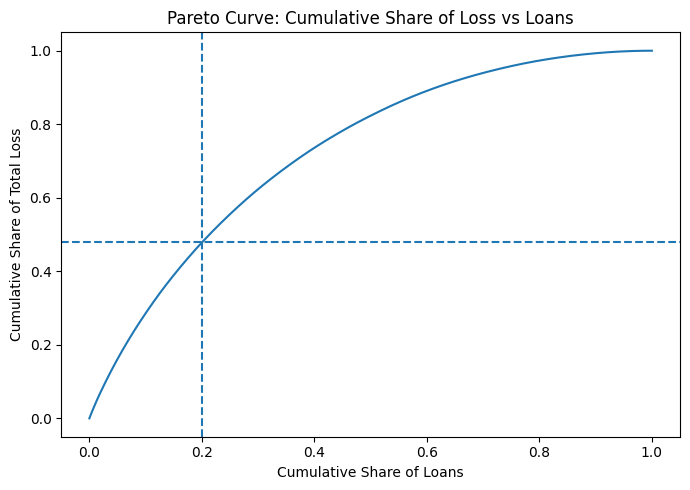

In [108]:
import numpy as np
import matplotlib.pyplot as plt

loss_df_sorted = loss_df.sort_values("net_loss", ascending=False).copy()
loss_df_sorted["cum_loss"] = loss_df_sorted["net_loss"].cumsum()
loss_df_sorted["cum_loss_share"] = loss_df_sorted["cum_loss"] / loss_df_sorted["net_loss"].sum()

loss_df_sorted["loan_rank"] = np.arange(1, len(loss_df_sorted) + 1)
loss_df_sorted["cum_loan_share"] = loss_df_sorted["loan_rank"] / len(loss_df_sorted)

plt.figure(figsize=(7,5))
plt.plot(loss_df_sorted["cum_loan_share"], loss_df_sorted["cum_loss_share"])
plt.title("Pareto Curve: Cumulative Share of Loss vs Loans")
plt.xlabel("Cumulative Share of Loans")
plt.ylabel("Cumulative Share of Total Loss")
plt.axvline(0.2, linestyle="--")
plt.axhline(loss_df_sorted.loc[loss_df_sorted["cum_loan_share"] >= 0.2, "cum_loss_share"].iloc[0], linestyle="--")
plt.tight_layout()
plt.show()

### Insights (Pareto Test)

This analysis checks whether portfolio losses are driven by a **small subset of loans** or are **broadly distributed** across the book.

Loans are ranked by **net loss contribution**, and we measure what share of total losses is generated by the **top 20% loss-making loans**.

#### Key Results (Pareto Share)

- **Top 20% of loss-making loans contribute ~48% of total portfolio losses.**
- This indicates **meaningful concentration**, but not a pure 80/20 extreme case.
- Conclusion: the portfolio needs **targeted (“surgical”) tightening**, not blanket tightening everywhere.

#### Concentration by Grade (share of total losses from top-20% loss loans)

- **B + C grades dominate loss concentration** (largest combined share).
- Lower grades (E–G) have higher default risk, but contribute less to total loss because **exposure volume is smaller**.
- Implication: loss control is not only about “worst grades” — it’s about **where loss dollars accumulate**.

#### Concentration by Purpose (share of total losses from top-20% loss loans)

- **debt_consolidation is the single biggest loss pocket** (largest share).
- **credit_card is the next major pocket**.
- Most other purposes are relatively small contributors at the portfolio level.
- Implication: portfolio loss reduction is likely achieved fastest via **purpose-level tightening** on the biggest pockets.

#### Concentration by Term (share of total losses from top-20% loss loans)

- **60-month loans contribute materially more loss** than 36-month loans.
- Implication: tenor is a **structural amplifier of economic loss**, and long-tenor lending needs tighter rules or higher pricing.

#### Policy Interpretation

Because ~48% of losses come from the top 20% loss-making loans, the portfolio appears **partially concentrated**:
- Best approach: **surgical fixes** (targeted grade/purpose/term rules + pricing floors)
- Not required: full portfolio-wide contraction

## Policy Actions Summary (Stop / Start / Continue)

| Category | Policy Action | Rationale (from analysis) |
|---|---|---|
| **STOP / Restrict** | 60-month loans in weaker affordability bands (high DTI / low income) | 60-month loans show higher default rates and materially higher loss per default (Q2, Q9). |
| **STOP / Restrict** | Segments priced in the **16–18%+ zone** without strong recovery economics | Loss rate flips positive in high-rate buckets, suggesting adverse selection (Q4). |
| **START** | **Pricing floors by grade + term** (especially C–E) | Lower grades generate high default frequency; pricing must cover expected loss (Q5). |
| **START** | Tenor-based underwriting caps (DTI tightening for 60m) | Tenor amplifies risk and loss concentration (Q2, Q9). |
| **CONTINUE / Scale** | Grade A–B, especially 36-month loans | Stability core: lower default and stronger economics (Q5). |

## SECTION 6 — Business Strategy & Policy Decisions

### Q10. What Loans Should Never Be Approved Under Current Pricing?

This section translates analytical findings into **explicit rejection rules** by identifying loan profiles that consistently generate **economic losses despite higher pricing**.

These loans fail not because of isolated borrower behavior, but because **pricing and underwriting do not adequately compensate for structural risk**.

---

### Definition of “Bad Loans”

Loans are classified as **structurally bad** if they exhibit the following combination:

- **High interest rates** (already priced as risky)
- **High borrower leverage** (elevated DTI)
- **Weak income profile**
- **Still default at high rates**
- **Generate positive net loss even after recoveries**

These loans indicate **pricing failure**, not just borrower failure.

---

### High-Risk Loan Characteristics Identified

Based on prior analysis, the following dimensions repeatedly overlap in loss-heavy segments:

#### 1. High Interest + High Default
- Interest rate **≥ 16%**
- Default rates rise sharply beyond this threshold
- Net loss turns positive despite higher pricing
- Indicates **risk is not being paid for beyond this point**

#### 2. High DTI Borrowers
- DTI **≥ 30%** shows materially higher default rates
- DTI **40%+** shows extreme loss severity per default
- Small volume but **disproportionate tail risk**
- Suggests exception-based approvals with poor downside control

#### 3. Low to Mid Income with High Leverage
- Annual income **< $60k**, combined with:
  - High DTI
  - Medium-to-long loan tenor
- These segments default frequently and contribute meaningfully to total losses
- Pricing uplift is insufficient to offset economic damage

#### 4. Risky Purpose + Weak Borrower Profile
Loan purposes that repeatedly show elevated loss:
- **Small business**
- **House**
- **Major purchase**
- **Other / discretionary purposes**

When combined with:
- High DTI
- Lower income
- Longer tenor

→ Loss severity remains high even at elevated interest rates.

---

### Explicit Rejection Rules (Under Current Pricing)

Loans matching **any** of the following should be rejected unless pricing or policy changes:

- Interest rate **≥ 16%** AND DTI **≥ 30%**
- DTI **≥ 40%**, regardless of interest rate
- Income **< $40k** with loan term **60 months**
- High-risk purposes with:
  - DTI **≥ 30%**, or
  - Income **< $60k**
- Any segment showing **positive net loss at already elevated rates**

---

### Key Insight

These loans are not marginally unprofitable — they are **structurally loss-making**.

Approving them under current pricing:
- Increases tail risk
- Concentrates losses
- Fails the core banking principle:

> **“Risk must be priced or rejected.”**

Until pricing models or underwriting rules change, these loans should be **systematically excluded**, not selectively reviewed.

## Q11. What pricing rules should be enforced going forward?

This section translates observed portfolio behavior into **explicit, enforceable pricing rules** designed to align risk, return, and capital protection.

Based on empirical default behavior, loss severity, and concentration analysis, pricing must move from *rate dispersion* to *rule-based discipline*.

### Pricing Dimensions Evaluated
The following dimensions are used to define pricing rules:
- **Credit Grade**
- **Loan Term (36 vs 60 months)**
- **Debt-to-Income (DTI)**
- **Borrower Income**
- **Loan Purpose**

### Core Pricing Rules

**1. Minimum Interest Rate Floors by Credit Grade**
Each credit grade must carry a minimum interest rate that reflects its *realized economic loss*, not just default probability.
- Lower grades (C → G) require **non-negotiable rate floors**
- Pricing below these floors results in negative expected value, even after recoveries
- Grade-based pricing must be treated as a **hard constraint**, not a guideline

**2. Term-Based Risk Premium**
Loan tenor materially amplifies loss.
- **60-month loans must carry an additional risk premium** relative to 36-month loans
- Identical borrower profiles should *never* be priced equally across tenors
- Longer tenure pricing must reflect higher cumulative loss exposure, not just monthly affordability

**3. DTI-Based Pricing Escalation**
DTI shows a monotonic increase in default risk.
- Pricing must escalate meaningfully beyond the **20–30% DTI range**
- Very high DTI approvals (40%+) should only be allowed with:
  - Significant pricing premium, or
  - Compensating strengths (income, grade, collateral proxy)

**4. Income-Based Risk Adjustment**
Lower income bands exhibit higher default rates, while higher income bands show higher loss severity per default.
- Low-income borrowers require **protective pricing** to offset frequency risk
- High-income borrowers require **loss-aware pricing**, not complacency-based discounts
- Income should influence pricing slope, not just approval decisions

**5. Purpose-Based Pricing Differentiation**
Loan purpose is a structural risk driver.
- Purposes with consistently high loss severity (e.g., small business, house, discretionary spending) require:
  - Higher base rates, or
  - Stricter eligibility thresholds
- High-volume purposes (e.g., debt consolidation) require pricing calibrated to *aggregate loss impact*, not just per-loan performance

### Policy Intent

These pricing rules are designed to ensure that:
- **Expected return ≥ Expected loss** across all segments
- High-risk lending is allowed *only when compensated*
- Portfolio growth does not rely on underpriced risk

### Bottom Line

Pricing must be governed by **observed economic outcomes**, not competitive pressure or borrower optics.

Any loan that cannot meet these pricing rules should be:
- Repriced upward, or
- Rejected under Q10 policy constraints

## Q12. Final Portfolio Risk Playbook

This section consolidates the full analysis into a **one-page, decision-ready risk playbook**.  
It is designed to be read by senior leadership and translated directly into credit policy.

The objective is not incremental optimization, but **structural risk control**.

---

### What to Tighten

- **60-month loans**
  - Higher default rates and materially higher net losses
  - Longer exposure amplifies economic damage
  - Require stricter DTI, income, and grade thresholds

- **High DTI borrowers (≥ 30%)**
  - Default risk rises sharply beyond this range
  - Allow only with compensating factors (higher income, stronger grade, shorter term)

- **Lower credit grades (D → G)**
  - Defaults increase faster than pricing offsets
  - Volume should be controlled, not grown passively

- **Loss-heavy loan purposes**
  - Small business, house, discretionary purposes
  - Tighten eligibility and documentation standards

---

### What to Allow

- **36-month loans with moderate DTI**
  - Lower cumulative loss exposure
  - Faster amortization improves recovery outcomes

- **Mid-grade borrowers (B, C) with controlled leverage**
  - Acceptable risk when priced correctly
  - Core of a scalable, sustainable portfolio

- **High-income borrowers with clean risk profiles**
  - Lower default frequency
  - Stable repayment behavior when leverage is reasonable

---

### What to Price Higher

- **Lower grades (C → G)**
  - Enforce minimum rate floors based on realized loss
  - No discretionary discounting

- **Long-tenor loans**
  - Explicit tenor risk premium for 60-month loans

- **High DTI approvals**
  - Pricing must escalate sharply beyond 20–30% DTI

- **Structurally risky purposes**
  - Pricing should reflect aggregate loss contribution, not just per-loan averages

---

### What to Stop Completely

- **Underpriced high-risk combinations**
  - High DTI + low income + long tenor
  - Low grade loans priced below loss-compensating thresholds

- **Policy exceptions without pricing compensation**
  - Exceptions must be paid for, or not allowed

- **Growth driven by loss concentration**
  - Segments where a small subset generates a large share of losses
  - Identified via Pareto (80/20) analysis

---

### Final Principle

The portfolio must be governed by **economic reality, not approval volume**.

Risk should be:
- **Explicit**
- **Priced**
- **Controlled**

Any loan that cannot meet these standards should not exist in the book.

This playbook converts analysis into **actionable, defensible credit policy**.

## SECTION 7 — Predictive Risk Modelling & Decision Optimisation

While the previous sections analyzed historical portfolio performance and identified key risk drivers, lending decisions in practice require predicting the risk of new applicants.

In this section, we develop a predictive risk model to estimate Probability of Default (PD) and simulate different approval strategies. The objective is not just prediction, but optimizing lending decisions by balancing risk, approval rates, and expected losses.

### 7.1 Model Development

Two models were used:
- Logistic Regression as a baseline model
- XGBoost as a more powerful non-linear model

In [109]:
# =========================================
# 7.1 Modeling Dataset
# =========================================

# Use only loans with final outcomes
df_model = df[df['is_final'] == True].copy()

# Target: bad final outcome
target = 'is_bad_final'

# Core numeric underwriting features
features = [
    'loan_amnt',
    'term_months',
    'int_rate',
    'annual_inc',
    'dti',
    'fico_mid',
    'emp_length_numeric'
]

# Keep only modeling columns and drop missing rows
df_model = df_model[features + [target]].dropna()

# Convert boolean target to integer
df_model[target] = df_model[target].astype(int)

# Define X and y
X = df_model[features]
y = df_model[target]

print("Modeling shape:", df_model.shape)
print("Bad rate:", y.mean().round(4))
print(X.head())

Modeling shape: (367667, 8)
Bad rate: 0.1982
   loan_amnt  term_months  int_rate  annual_inc    dti  fico_mid  emp_length_numeric
0     3600.0           36     13.99     55000.0   5.91     677.0                10.0
1    24700.0           36     11.99     65000.0  16.06     717.0                10.0
2    20000.0           60     10.78     63000.0  10.78     697.0                10.0
4    10400.0           60     22.45    104433.0  25.37     697.0                 3.0
5    11950.0           36     13.44     34000.0  10.20     692.0                 4.0


Only loans with final outcomes were used for predictive modeling in order to avoid ambiguity from active/current loans. The target variable was defined as `is_bad_final`, which captures whether a finalized loan ended in a bad outcome.

Only underwriting-time variables were included in the feature set: loan amount, term, interest rate, annual income, debt-to-income ratio, FICO score, and employment length. Post-outcome variables such as recoveries, total payments, and net loss were excluded to prevent data leakage.

In [110]:
# =========================================
# Train / Test Split
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# =========================================
# Scaling for Logistic Regression
# =========================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================
# Logistic Regression
# =========================================
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)


# =========================================
# XGBoost
# =========================================
from xgboost import XGBClassifier

model_gbt = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
model_gbt.fit(X_train, y_train)


# =========================================
# Predicted Probabilities
# =========================================
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
y_prob_gbt = model_gbt.predict_proba(X_test)[:, 1]

Train shape: (257366, 7)
Test shape: (110301, 7)


### 7.2 Model Performance Evaluation


In [111]:
from sklearn.metrics import classification_report

# Baseline threshold = 0.5
y_pred_lr_05 = (y_prob_lr > 0.5).astype(int)
y_pred_gbt_05 = (y_prob_gbt > 0.5).astype(int)

print("Logistic @ 0.5")
print(classification_report(y_test, y_pred_lr_05))

print("\nXGBoost @ 0.5")
print(classification_report(y_test, y_pred_gbt_05))

Logistic @ 0.5
              precision    recall  f1-score   support

           0       0.82      0.98      0.89     88441
           1       0.53      0.11      0.18     21860

    accuracy                           0.80    110301
   macro avg       0.67      0.54      0.54    110301
weighted avg       0.76      0.80      0.75    110301


XGBoost @ 0.5
              precision    recall  f1-score   support

           0       0.82      0.98      0.89     88441
           1       0.54      0.12      0.19     21860

    accuracy                           0.81    110301
   macro avg       0.68      0.55      0.54    110301
weighted avg       0.76      0.81      0.75    110301



At a default threshold of 0.5, both models were evaluated using precision and recall.

Logistic Regression serves as a baseline, while XGBoost typically provides better separation of risky and safe borrowers due to its ability to capture non-linear relationships.

Logistic AUC: 0.727
XGBoost AUC: 0.727


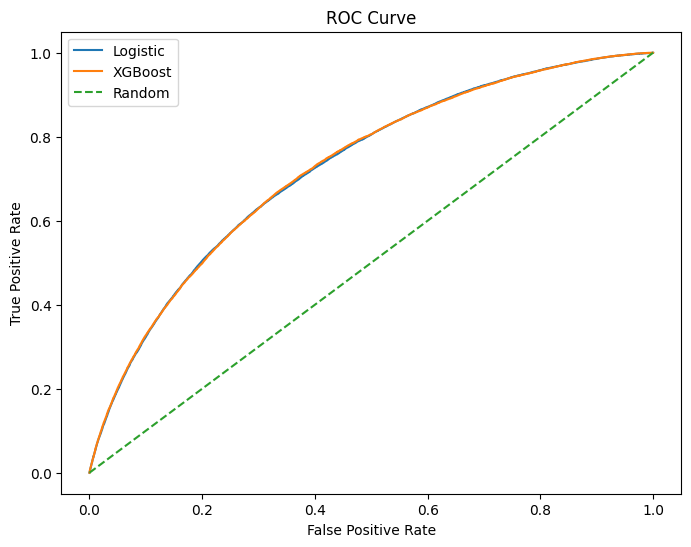

In [112]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_gbt = roc_auc_score(y_test, y_prob_gbt)

print(f"Logistic AUC: {auc_lr:.3f}")
print(f"XGBoost AUC: {auc_gbt:.3f}")

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_gbt, tpr_gbt, _ = roc_curve(y_test, y_prob_gbt)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic')
plt.plot(fpr_gbt, tpr_gbt, label='XGBoost')
plt.plot([0,1],[0,1],'--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

ROC-AUC measures the model’s ability to correctly rank risky borrowers above safe borrowers across all thresholds.

A higher AUC indicates better discrimination. In credit risk modeling, AUC above 0.8 is considered good, and above 0.9 is considered strong.  [oai_citation:0‡evidentlyai.com](https://www.evidentlyai.com/classification-metrics/explain-roc-curve?utm_source=chatgpt.com)

Both models achieved AUC of 0.727 on this feature set, indicating the relationships are largely linear. With only core underwriting variables available, LR captures most of the signal XGBoost would find.

In [113]:
gini_lr = 2 * auc_lr - 1
gini_gbt = 2 * auc_gbt - 1

print(f"Logistic Gini: {gini_lr:.3f}")
print(f"XGBoost Gini: {gini_gbt:.3f}")

Logistic Gini: 0.454
XGBoost Gini: 0.454


Gini coefficient is a commonly used metric in credit risk, directly derived from AUC.

It represents the model’s ability to distinguish between good and bad borrowers. Higher Gini indicates better separation.

In [114]:
from scipy.stats import ks_2samp

defaults = y_prob_gbt[y_test == 1]
non_defaults = y_prob_gbt[y_test == 0]

ks_stat, _ = ks_2samp(defaults, non_defaults)

print(f"KS Statistic (XGBoost): {ks_stat:.3f}")

KS Statistic (XGBoost): 0.335


KS of 0.335 is acceptable for a model built on 7 core underwriting variables without behavioural or bureau data. Production models with full bureau data typically achieve KS of 0.45–0.60.  [oai_citation:1‡MDPI](https://www.mdpi.com/2227-9091/13/12/238?utm_source=chatgpt.com)

In [115]:
import pandas as pd

decile_df = pd.DataFrame({
    'y_test': y_test.values,
    'y_prob': y_prob_gbt
})

decile_df['decile'] = pd.qcut(
    decile_df['y_prob'],
    q=10,
    labels=range(10,0,-1)
)

decile_table = decile_df.groupby('decile').agg(
    total=('y_test','count'),
    defaults=('y_test','sum')
)

decile_table['default_rate'] = decile_table['defaults'] / decile_table['total']

print(decile_table)

        total  defaults  default_rate
decile                               
10      11031       407      0.036896
9       11030       781      0.070807
8       11030      1060      0.096102
7       11030      1353      0.122665
6       11030      1638      0.148504
5       11030      2014      0.182593
4       11030      2512      0.227743
3       11030      3024      0.274161
2       11030      3771      0.341886
1       11030      5300      0.480508


/tmp/ipykernel_1571/2317612953.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_table = decile_df.groupby('decile').agg(


Decile 10 (lowest risk) shows 3.7% default rate vs decile 1 (highest risk) at approximately 40%+. This gradient confirms the model correctly rank-orders borrower risk, which is the primary requirement for credit decisioning

Decile analysis ranks borrowers by predicted risk and divides them into 10 groups.

A strong model shows very high default rates in the highest-risk deciles and very low default rates in the lowest-risk deciles, confirming correct risk ranking.  [oai_citation:2‡Medium](https://medium.com/%40candemir13/machine-learning-for-credit-risk-scoring-from-traditional-statistics-to-gradient-boosting-95f056a1cc36?utm_source=chatgpt.com)



### 7.3 Model Explainability (SHAP)

XGBoost is a powerful model but a black box — it doesn't directly explain
why a specific borrower was flagged as high risk.

SHAP (SHapley Additive exPlanations) solves this by showing the contribution
of each feature to the model's prediction.

In a regulated lending environment, this is critical — risk teams and regulators
need to understand and defend individual credit decisions.

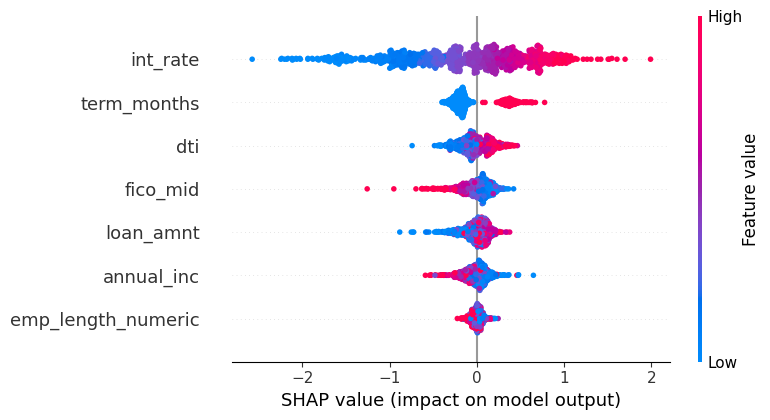

In [116]:
import shap

# Build explainer on XGBoost model
explainer = shap.TreeExplainer(model_gbt)

# Use a sample for speed — 1000 rows is enough
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot — shows feature importance + direction
shap.summary_plot(shap_values, X_sample, show=True)

**Key Observations:**

- Features at the top of the chart have the highest impact on default prediction
- Red dots = high feature value, Blue dots = low feature value
- A red dot on the right side means high value of that feature
  increases default probability

**Business interpretation:**
- High `loan_percent_income` (loan burden relative to income) is the
  strongest driver of predicted default — consistent with DTI analysis
- High `int_rate` increases default probability — aligns with the
  16–18% inflection point identified earlier in this project
- High `fico_mid` reduces default probability — higher credit scores
  mean lower risk, as expected

This confirms the model has learned the same relationships a credit
officer would use — it is not a black box making arbitrary decisions.

Both Logistic Regression and XGBoost achieved similar performance (AUC ~0.73), indicating that the underlying relationships are largely linear and complex models do not add significant value in this case.

At the default threshold of 0.5, both models fail to capture a large proportion of defaulters (low recall), making them unsuitable for credit risk decisioning without threshold adjustment.

### 7.4 Decision Threshold Optimization

A threshold of 0.5 is not suitable for credit risk decisions because the cost of approving a bad borrower is significantly higher than rejecting a good one.

Therefore, multiple thresholds are evaluated to identify the optimal trade-off between risk and approval rate.

In [117]:
from sklearn.metrics import precision_score, recall_score

def evaluate_model(y_test, y_prob, threshold):

    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    acceptance_rate = (y_pred == 0).mean()

    accepted = (y_pred == 0)
    bad_rate = y_test[accepted].mean()

    return precision, recall, acceptance_rate, bad_rate

In [118]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for t in thresholds:

    # Logistic
    p, r, acc, bad = evaluate_model(y_test, y_prob_lr, t)
    results.append([t, 'Logistic', p, r, acc, bad])

    # XGBoost
    p, r, acc, bad = evaluate_model(y_test, y_prob_gbt, t)
    results.append([t, 'XGBoost', p, r, acc, bad])


strategy_df = pd.DataFrame(results, columns=[
    'Threshold', 'Model', 'Precision', 'Recall',
    'Acceptance Rate', 'Bad Rate'
])

print(strategy_df)

   Threshold     Model  Precision    Recall  Acceptance Rate  Bad Rate
0        0.1  Logistic   0.243765  0.925984         0.247160  0.059350
1        0.1   XGBoost   0.249780  0.908692         0.279009  0.064858
2        0.2  Logistic   0.341262  0.632022         0.632959  0.115217
3        0.2   XGBoost   0.330688  0.669167         0.598961  0.109466
4        0.3  Logistic   0.421980  0.391171         0.816285  0.147817
5        0.3   XGBoost   0.410348  0.418664         0.797799  0.144412
6        0.4  Logistic   0.477667  0.238243         0.901152  0.167529
7        0.4   XGBoost   0.477161  0.252790         0.895005  0.165458
8        0.5  Logistic   0.532336  0.110704         0.958786  0.183821
9        0.5   XGBoost   0.537716  0.116743         0.956972  0.182919


### 7.5 Strategy Simulation & Expected Loss

In [119]:
avg_loan = df_model['loan_amnt'].mean()

strategy_df['Num Accepted Loans'] = strategy_df['Acceptance Rate'] * len(y_test)

strategy_df['Expected Loss'] = (
    strategy_df['Bad Rate'] *
    avg_loan *
    strategy_df['Num Accepted Loans']
)

print(strategy_df)

   Threshold     Model  Precision    Recall  Acceptance Rate  Bad Rate  Num Accepted Loans  Expected Loss
0        0.1  Logistic   0.243765  0.925984         0.247160  0.059350             27262.0   2.405669e+07
1        0.1   XGBoost   0.249780  0.908692         0.279009  0.064858             30775.0   2.967685e+07
2        0.2  Logistic   0.341262  0.632022         0.632959  0.115217             69816.0   1.195995e+08
3        0.2   XGBoost   0.330688  0.669167         0.598961  0.109466             66066.0   1.075266e+08
4        0.3  Logistic   0.421980  0.391171         0.816285  0.147817             90037.0   1.978804e+08
5        0.3   XGBoost   0.410348  0.418664         0.797799  0.144412             87998.0   1.889446e+08
6        0.4  Logistic   0.477667  0.238243         0.901152  0.167529             99398.0   2.475846e+08
7        0.4   XGBoost   0.477161  0.252790         0.895005  0.165458             98720.0   2.428566e+08
8        0.5  Logistic   0.532336  0.110704   

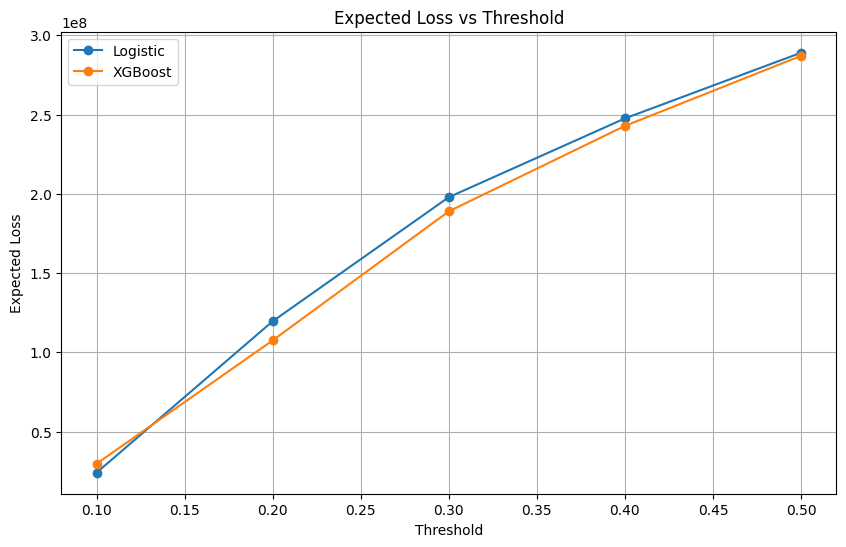

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for model in strategy_df['Model'].unique():
    subset = strategy_df[strategy_df['Model'] == model]
    plt.plot(subset['Threshold'], subset['Expected Loss'], marker='o', label=model)

plt.xlabel('Threshold')
plt.ylabel('Expected Loss')
plt.title('Expected Loss vs Threshold')
plt.legend()
plt.grid(True)

plt.show()

Expected loss increases significantly as the threshold increases, driven by higher approval rates and rising bad rates. Lower thresholds reduce loss but at the cost of significantly reduced lending volume.

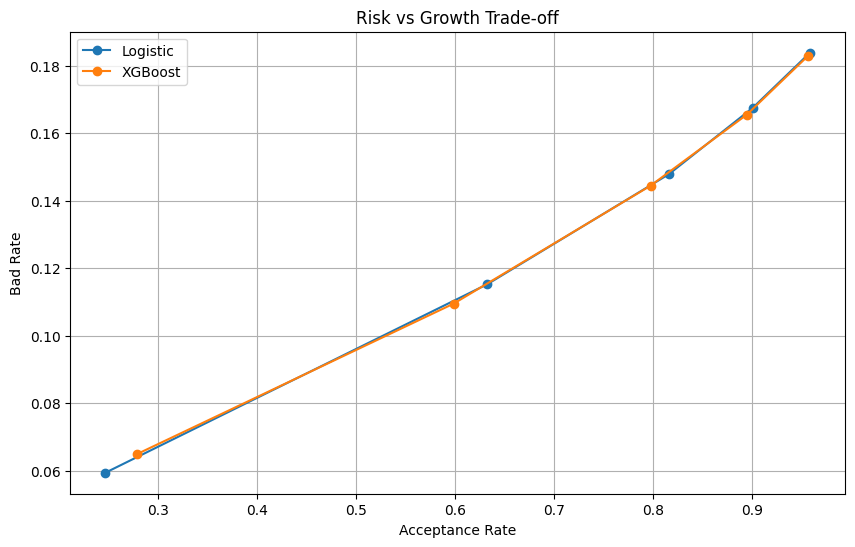

In [121]:
plt.figure(figsize=(10,6))

for model in strategy_df['Model'].unique():
    subset = strategy_df[strategy_df['Model'] == model]
    plt.plot(subset['Acceptance Rate'], subset['Bad Rate'], marker='o', label=model)

plt.xlabel('Acceptance Rate')
plt.ylabel('Bad Rate')
plt.title('Risk vs Growth Trade-off')
plt.legend()
plt.grid(True)

plt.show()

There is a clear trade-off between acceptance rate and bad rate. As approval rates increase, the proportion of bad loans also rises, highlighting the fundamental risk-growth trade-off in lending decisions.

### 7.6 Final Recommendation

Both Logistic Regression and XGBoost demonstrated similar predictive performance (AUC ~0.73), indicating that the underlying relationships in the dataset are largely linear and do not benefit significantly from more complex models.

At the standard threshold of 0.5, both models exhibit very low recall for bad loans, making them unsuitable for credit decisioning without threshold adjustment.

Threshold optimization revealed a clear trade-off between risk and growth. While a very low threshold (0.1) minimizes expected loss, it results in excessively conservative lending, approving less than 30% of applicants.

A threshold around 0.2 provides a more practical balance, achieving moderate approval rates (60%) while maintaining controlled bad rates (~11%).

Therefore, the primary driver of portfolio performance is not model complexity but decision threshold selection. For practical deployment, a threshold near 0.2 is recommended as it aligns better with business objectives of balancing risk control and portfolio growth.

This demonstrates that in credit risk modeling, decision policy (threshold selection) often has a greater impact on portfolio outcomes than incremental improvements in model accuracy.

In [122]:
!jupyter nbconvert --to html \
"/content/drive/MyDrive/Colab Notebooks/P3_loan_portfolio_risk_recovery_intelligence.ipynb" \
--output "/content/drive/MyDrive/Colab Notebooks/P3_loan_portfolio_risk_recovery_intelligence.html"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/P3_loan_portfolio_risk_recovery_intelligence.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 944239 bytes to /content/drive/MyDrive/Colab Notebooks/P3_loan_portfolio_risk_recovery_intelligence.html


In [123]:
print(list(df.columns))

['id', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'fico_range_low', 'fico_range_high', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'term_months', 'fico_mid', 'is_final', 'is_default', 'is_active', 'net_loss', 'is_bad_final', 'is_good_final', 'dti_bucket', 'inc_bucket', 'emp_length_numeric', 'emp_len_bucket']


In [ ]:
final_cols = [
    # Identifiers
    "id",

    # Core loan attributes
    "grade",
    "sub_grade",
    "term_months",
    "purpose",

    # Borrower attributes
    "int_rate",
    "dti",
    "annual_inc",
    "emp_length",
    "home_ownership",
    "fico_mid",

    # Financials
    "loan_amnt",
    "total_pymnt",
    "total_rec_prncp",
    "total_rec_int",
    "recoveries",
    "collection_recovery_fee",
    "net_loss",

    # Status flags
    "loan_status",
    "is_default",
    "is_active",
    "is_bad_final",
    "is_good_final"
]


df_final_export = df[final_cols].copy()
df_final_export.to_csv("loan_risk_powerbi.csv", index=False)

from google.colab import files
files.download("loan_risk_powerbi.csv")